In [1]:
import os
import pickle
import re
import gc
from pathlib import Path

import pandas as pd
import numpy as np
from utils.model_saver import *


def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists() and (candidate / 'Models').exists() and (candidate / 'notebooks').exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")

PATH_DATA = PROJECT_ROOT / 'data'
PATH_NORMAL_DATA = PATH_DATA / 'normal_features'
PATH_GRAPH_DATA = PATH_DATA / 'graph_features'
PATH_TEXT_DATA = PATH_DATA / 'textual_features'
PATH_COMBINED_DATA = PATH_DATA / 'combined_features'
MODELS_SAVE_PATH = PROJECT_ROOT / 'Models'

SAVE = True
PATH_PLOTS = PROJECT_ROOT / 'report' / 'src'
TARGET = 'is_reference_valid'
RANDOM_STATE = 42

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# Keep prediction memory use predictable.
N_JOBS = 1


Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Using device: cuda


In [2]:
import gc
import pandas as pd

from sklearn.preprocessing import RobustScaler


ID_COLUMNS = ["article_id", "ref_id"]
TARGET_COL = "is_reference_valid"
RANDOM_STATE = 42


def load_scale_sample(
    train_path,
    test_path=None,
    sample_size=20_000,
    target_col=TARGET_COL,
    id_columns=ID_COLUMNS,
    split_col="split",
    random_state=RANDOM_STATE,
):
    # Case 1: train/test are in two separate files
    if test_path is not None:
        train = pd.read_parquet(train_path)
        test = pd.read_parquet(test_path)

    # Case 2: train/test are in one file with split column
    else:
        df = pd.read_parquet(train_path)
        split = df[split_col].astype(str).str.lower()
        train = df[split == "train"].copy()
        test = df[split == "test"].copy()
        del df, split
        gc.collect()

    train = train.drop(columns=list(id_columns) + [split_col], errors="ignore")
    test = test.drop(columns=list(id_columns) + [split_col], errors="ignore")

    y_train = train[target_col].copy()
    y_test = test[target_col].copy()

    X_train = train.drop(columns=[target_col])
    X_test = test.drop(columns=[target_col])

    num_cols = X_train.select_dtypes(include="number").columns

    scaler = RobustScaler()

    train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train[num_cols]),
        columns=num_cols,
        index=X_train.index,
    )

    test_scaled = pd.DataFrame(
        scaler.transform(X_test[num_cols]),
        columns=num_cols,
        index=X_test.index,
    )

    train_scaled[target_col] = y_train.values
    test_scaled[target_col] = y_test.values

    del train, test, X_train, X_test, y_train, y_test
    gc.collect()

    train_scaled = train_scaled.sample(
        n=min(sample_size, len(train_scaled)),
        random_state=random_state,
    ).reset_index(drop=True)

    test_scaled = test_scaled.sample(
        n=min(sample_size, len(test_scaled)),
        random_state=random_state,
    ).reset_index(drop=True)

    gc.collect()

    return train_scaled, test_scaled, scaler

In [3]:
ID_COLUMNS = ["article_id", "ref_id"]
NON_FEATURE_COLUMNS = ID_COLUMNS + ["split"]

norm_train, norm_test, norm_scaler = load_scale_sample(
    PATH_NORMAL_DATA / "train.parquet",
    PATH_NORMAL_DATA / "test.parquet",
)

graph_train, graph_test, graph_scaler = load_scale_sample(
    PATH_GRAPH_DATA / "final_train.parquet",
    PATH_GRAPH_DATA / "final_test.parquet",
)

text64_train, text64_test, text64_scaler = load_scale_sample(
    PATH_TEXT_DATA / "textual_embeddings_64.parquet",
    test_path=None, sample_size=2_000 
)

text128_train, text128_test, text128_scaler = load_scale_sample(
    PATH_TEXT_DATA / "textual_embeddings_128.parquet",
    test_path=None, sample_size=2_000
)

mix_train, mix_test, mix_scaler = load_scale_sample(
    PATH_COMBINED_DATA / "train.parquet",
    PATH_COMBINED_DATA / "test.parquet",
    sample_size=2000
)

In [4]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


def load_latest_models(base_path='./Models'):
    """
    Creates a nested dictionary registry.
    Access via: registry['folder_name']['KNN']
    """
    models_registry = {}
    base_dir = Path(base_path)

    if not base_dir.exists():
        print(f"Error: Directory {base_path} not exist.")
        return models_registry

    model_types = {
        'KNN': 'Best_KNN',
        'XGB': 'Best_XGB',
        'transformer': 'Transformer'
    }

    for subdir in base_dir.iterdir():
        if subdir.is_dir():
            models_registry[subdir.name] = {}
            for label, keyword in model_types.items():
                model_files = [f for f in subdir.glob(f'*{keyword}*.pkl')]
                if not model_files:
                    continue

                latest_file = sorted(model_files, key=lambda x: x.name)[-1]
                try:
                    with open(latest_file, 'rb') as f:
                        model = pickle.load(f)
                    if hasattr(model, 'set_params') and 'n_jobs' in model.get_params():
                        model.set_params(n_jobs=N_JOBS)
                    models_registry[subdir.name][label] = model
                    print(f"Loaded {label} from {subdir.name}: {latest_file.name}")
                except Exception as e:
                    print(f"Failed to load {label} in {subdir.name}: {e}")

    return models_registry



def _as_flat_model_input(X):
    """Return a numeric 2D array for sklearn/XGBoost-style models."""
    if hasattr(X, "to_numpy"):
        return X.to_numpy(dtype=np.float32, copy=False)
    return np.asarray(X, dtype=np.float32)


def _pair_embedding_dim(model):
    """Return expected per-embedding width for pair transformers, if detectable."""
    torch_model = getattr(model, "model", None)
    input_projection = getattr(torch_model, "input_projection", None)
    return getattr(input_projection, "in_features", None)


def _as_pair_transformer_input(model, X):
    """Reshape flat pair embeddings from (n, 2*d) to (n, 2, d)."""
    embedding_dim = _pair_embedding_dim(model)
    if embedding_dim is None:
        return None

    X_array = _as_flat_model_input(X)
    if X_array.ndim != 2 or X_array.shape[1] % embedding_dim != 0:
        return None

    n_parts = X_array.shape[1] // embedding_dim
    if n_parts < 2:
        return None

    return X_array.reshape(X_array.shape[0], n_parts, embedding_dim)


def _predict_safely(model, X):
    pair_input = _as_pair_transformer_input(model, X)
    if pair_input is not None:
        try:
            return model.predict(pair_input)
        except (ValueError, RuntimeError):
            pass

    try:
        return model.predict(X)
    except (ValueError, RuntimeError) as exc:
        flat_input = _as_flat_model_input(X)
        try:
            return model.predict(flat_input)
        except (ValueError, RuntimeError):
            if pair_input is not None:
                return model.predict(pair_input)
            raise exc


def evaluate_model_on_sets(model, set_dict):
    """
    Evaluates a single model on its specific dictionary of sets.
    Returns a dict with confusion matrices and a dataframe of metrics.
    """
    results = {'cms': {}, 'metrics': []}

    for set_name, (X, y) in set_dict.items():
        y_pred = _predict_safely(model, X)
        results['cms'][set_name] = confusion_matrix(y, y_pred)
        results['metrics'].append({
            'Set': set_name,
            'F1': f1_score(y, y_pred, average='weighted', zero_division=0),
            'Accuracy': accuracy_score(y, y_pred),
            'Precision': precision_score(y, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y, y_pred, average='weighted', zero_division=0)
        })
        del y_pred

    results['metrics_df'] = pd.DataFrame(results['metrics']).set_index('Set')
    return results


def plot_model_comparison(model_list, model_names, all_sets_list, title="Model Comparison", figsize=(18, 10)):
    """
    Plot confusion matrices and basic metrics. Returns (fig, metrics_df).
    """
    if not model_list:
        raise ValueError("model_list is empty: nothing to plot.")

    n_models = len(model_list)
    set_names = list(all_sets_list[0].keys())
    n_sets = len(set_names)

    fig, axes = plt.subplots(n_sets, n_models + 1, figsize=figsize, constrained_layout=True)
    axes = np.asarray(axes).reshape(n_sets, n_models + 1)
    fig.suptitle(title, fontsize=20, fontweight='bold')

    all_evaluations = []
    metrics_rows = []

    for i, (model, m_name, s_dict) in enumerate(zip(model_list, model_names, all_sets_list)):
        res = evaluate_model_on_sets(model, s_dict)
        all_evaluations.append(res)

        for set_name, row in res['metrics_df'].iterrows():
            row_dict = row.to_dict()
            row_dict['Model_Type'] = m_name
            row_dict['Set'] = set_name
            metrics_rows.append(row_dict)

        for j, s_name in enumerate(set_names):
            ax = axes[j, i]
            sns.heatmap(res['cms'][s_name], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
            ax.set_title(f"{m_name} - {s_name}")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")

    for j, s_name in enumerate(set_names):
        ax = axes[j, -1]
        stats_data = []
        for idx, m_name in enumerate(model_names):
            m_metrics = all_evaluations[idx]['metrics_df'].loc[s_name]
            for metric_name in ['F1', 'Accuracy']:
                stats_data.append({'Model': m_name, 'Metric': metric_name, 'Score': m_metrics[metric_name]})

        df_plot = pd.DataFrame(stats_data)
        sns.barplot(data=df_plot, x='Score', y='Metric', hue='Model', ax=ax)
        ax.set_xlim(0, 1.0)
        ax.set_title(f"Global Stats - {s_name}")
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    metrics_df = pd.DataFrame(metrics_rows).set_index(['Model_Type', 'Set'])
    return fig, metrics_df


def save_show_close(fig, filename):
    output_path = PATH_PLOTS / filename
    if SAVE:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, bbox_inches='tight', dpi=150)
        print(f"Saved figure: {output_path}")
    display(fig)
    plt.close(fig)
    return output_path


def separe_dataset(dataset, target='is_reference_valid'):
    columns_to_drop = [target, "split", *ID_COLUMNS]
    X = dataset.drop(columns=columns_to_drop, errors="ignore")
    y = dataset[target]
    return X, y


def set_dict(datasets, names=['train', 'test'], target='is_reference_valid'):
    res_dict = {}
    for df, name in zip(datasets, names):
        X, y = separe_dataset(df, target=target)
        res_dict[name] = (X, y)
    return res_dict


# Models Comparison


## 1. Import Pretrained Models

In [5]:
# Usage
models_dict = load_latest_models(MODELS_SAVE_PATH)

# Helper function to safely get models
def get_model_safe(models_dict, folder, model_type):
    """Safely get a model, returning None if not available"""
    if folder in models_dict and model_type in models_dict[folder]:
        return models_dict[folder][model_type]
    print(f"⚠️  Warning: {model_type} not found in {folder}")
    return None

# Initial Features (only KNN available)
initial_feat_knn = get_model_safe(models_dict, 'initial_features', 'KNN')
initial_feat_xgb = get_model_safe(models_dict, 'initial_features', 'XGB')
initial_feat_transformer = get_model_safe(models_dict, 'initial_features', 'transformer')

# Graph Features
graph_feat_knn = get_model_safe(models_dict, 'graph_features', 'KNN')
graph_feat_xgb = get_model_safe(models_dict, 'graph_features', 'XGB')
graph_feat_transformer = get_model_safe(models_dict, 'graph_features', 'transformer')

# Textual 64
text64_feat_knn = get_model_safe(models_dict, 'textual_embeddings_64', 'KNN')
text64_feat_xgb = get_model_safe(models_dict, 'textual_embeddings_64', 'XGB')
text64_feat_transformer = get_model_safe(models_dict, 'textual_embeddings_64', 'transformer')

# Textual 128
text128_feat_knn = get_model_safe(models_dict, 'textual_embeddings_128', 'KNN')
text128_feat_xgb = get_model_safe(models_dict, 'textual_embeddings_128', 'XGB')
text128_feat_transformer = get_model_safe(models_dict, 'textual_embeddings_128', 'transformer')

# All Features
all_feat_knn = get_model_safe(models_dict, 'all_features', 'KNN')
all_feat_xgb = get_model_safe(models_dict, 'all_features', 'XGB')
all_feat_transformer = get_model_safe(models_dict, 'all_features', 'transformer')

comparison_metrics = {}
comparison_figure_paths = {}


Loaded transformer from exploded_splits: Transformer_diff_concept_20260502_161219.pkl
Loaded KNN from initial_features: Best_KNN_initial_based_20260503_235716.pkl
Loaded KNN from textual_embeddings_64: Best_KNN_textual_64_20260430_132326.pkl
Loaded XGB from textual_embeddings_64: Best_XGB_textual_64_20260430_144945.pkl
Loaded transformer from textual_embeddings_64: Best_Transformer_textual_64_20260430_142545.pkl
Loaded KNN from graph_features: Best_KNN_graph_based_20260502_190500.pkl
Loaded XGB from graph_features: Best_XGB_graph_20260430_152157.pkl
Loaded transformer from graph_features: Transformer_graph_20260430_164512.pkl
Loaded KNN from textual_embeddings_128: Best_KNN_textual_128_20260430_134647.pkl
Loaded XGB from textual_embeddings_128: Best_XGB_textual_128_20260430_152616.pkl
Loaded transformer from textual_embeddings_128: Best_Transformer_textual_128_20260430_161040.pkl
Loaded KNN from all_features: Best_KNN_all_features_20260503_212618.pkl
Loaded XGB from all_features: Best_

## 2. Comparison by feature types

### 2.1 Initial Features

/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_normal.png


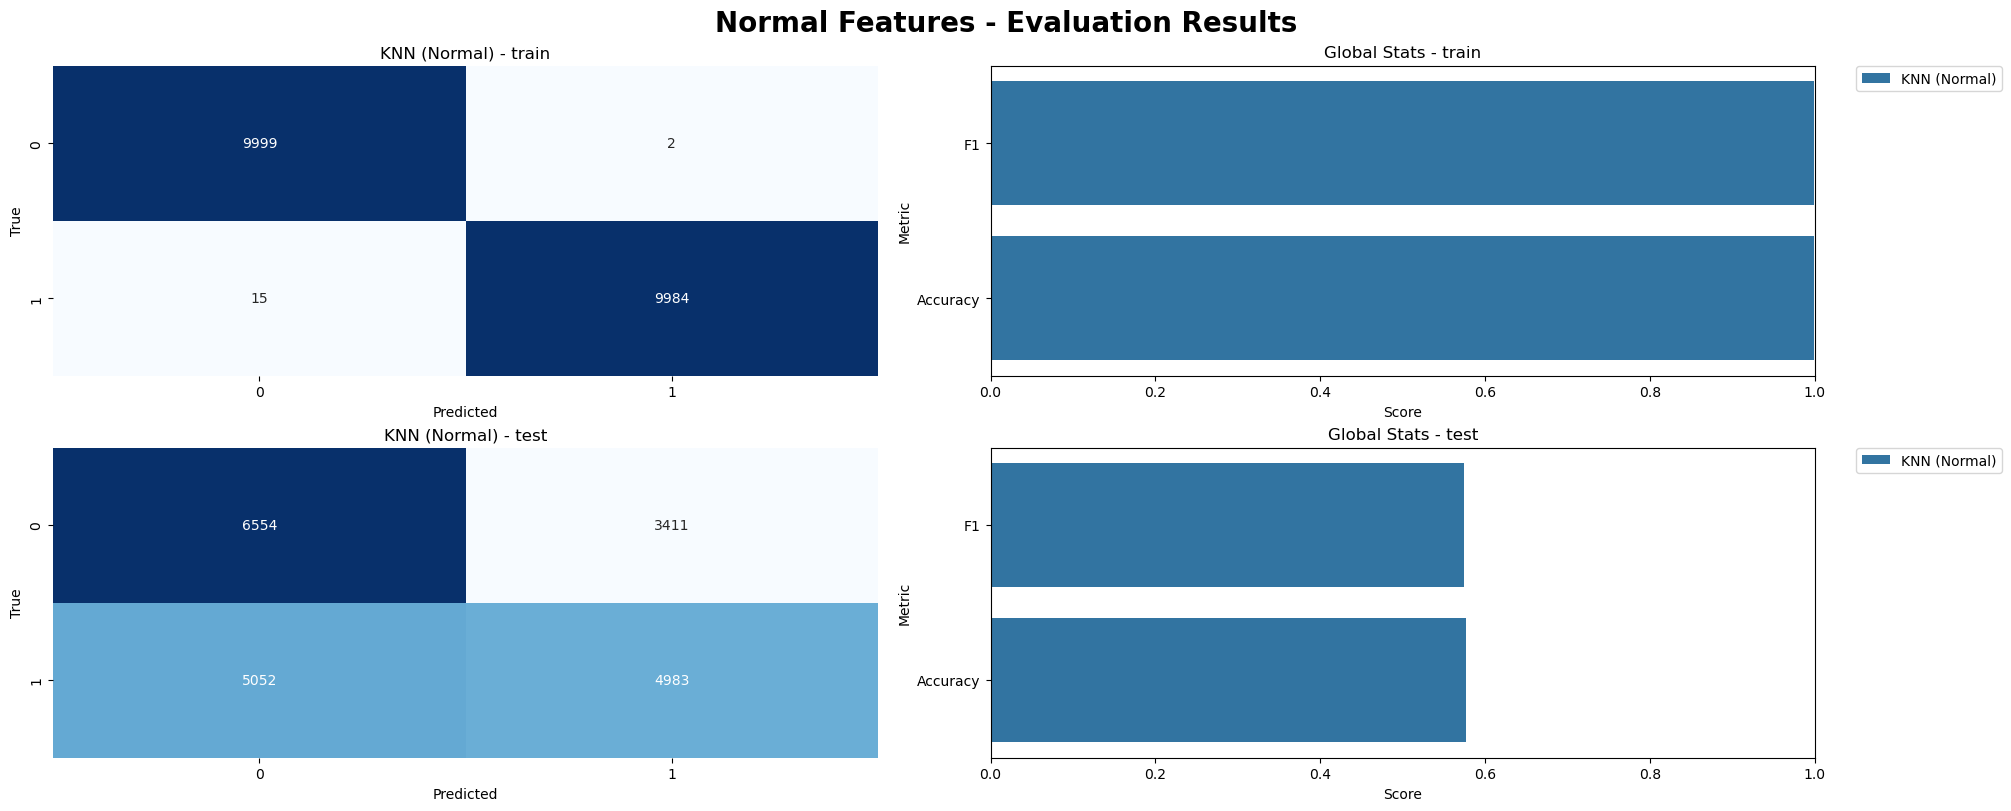

In [6]:
sets_for_normal = set_dict(datasets=[norm_train, norm_test], names=['train', 'test'])

initial_feat_models = [m for m in [initial_feat_knn, initial_feat_xgb, initial_feat_transformer] if m is not None]
initial_feat_models_names = []
if initial_feat_knn is not None:
    initial_feat_models_names.append('KNN (Normal)')
if initial_feat_xgb is not None:
    initial_feat_models_names.append('XGB (Normal)')
if initial_feat_transformer is not None:
    initial_feat_models_names.append('Transformer (Normal)')

if initial_feat_models:
    initial_feat_fig, initial_feat_metrics = plot_model_comparison(
        model_list=initial_feat_models,
        model_names=initial_feat_models_names,
        all_sets_list=[sets_for_normal] * len(initial_feat_models),
        title="Normal Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['initial_features'] = initial_feat_metrics
    comparison_figure_paths['initial_features'] = save_show_close(initial_feat_fig, 'eval_models_normal.png')
else:
    print("No models available for Initial Features")


### 2.2 Graph Features

/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [01:49:10] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This w

predict:   0%|          | 0/40 [00:00<?, ?it/s]

predict:   0%|          | 0/40 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_graph.png


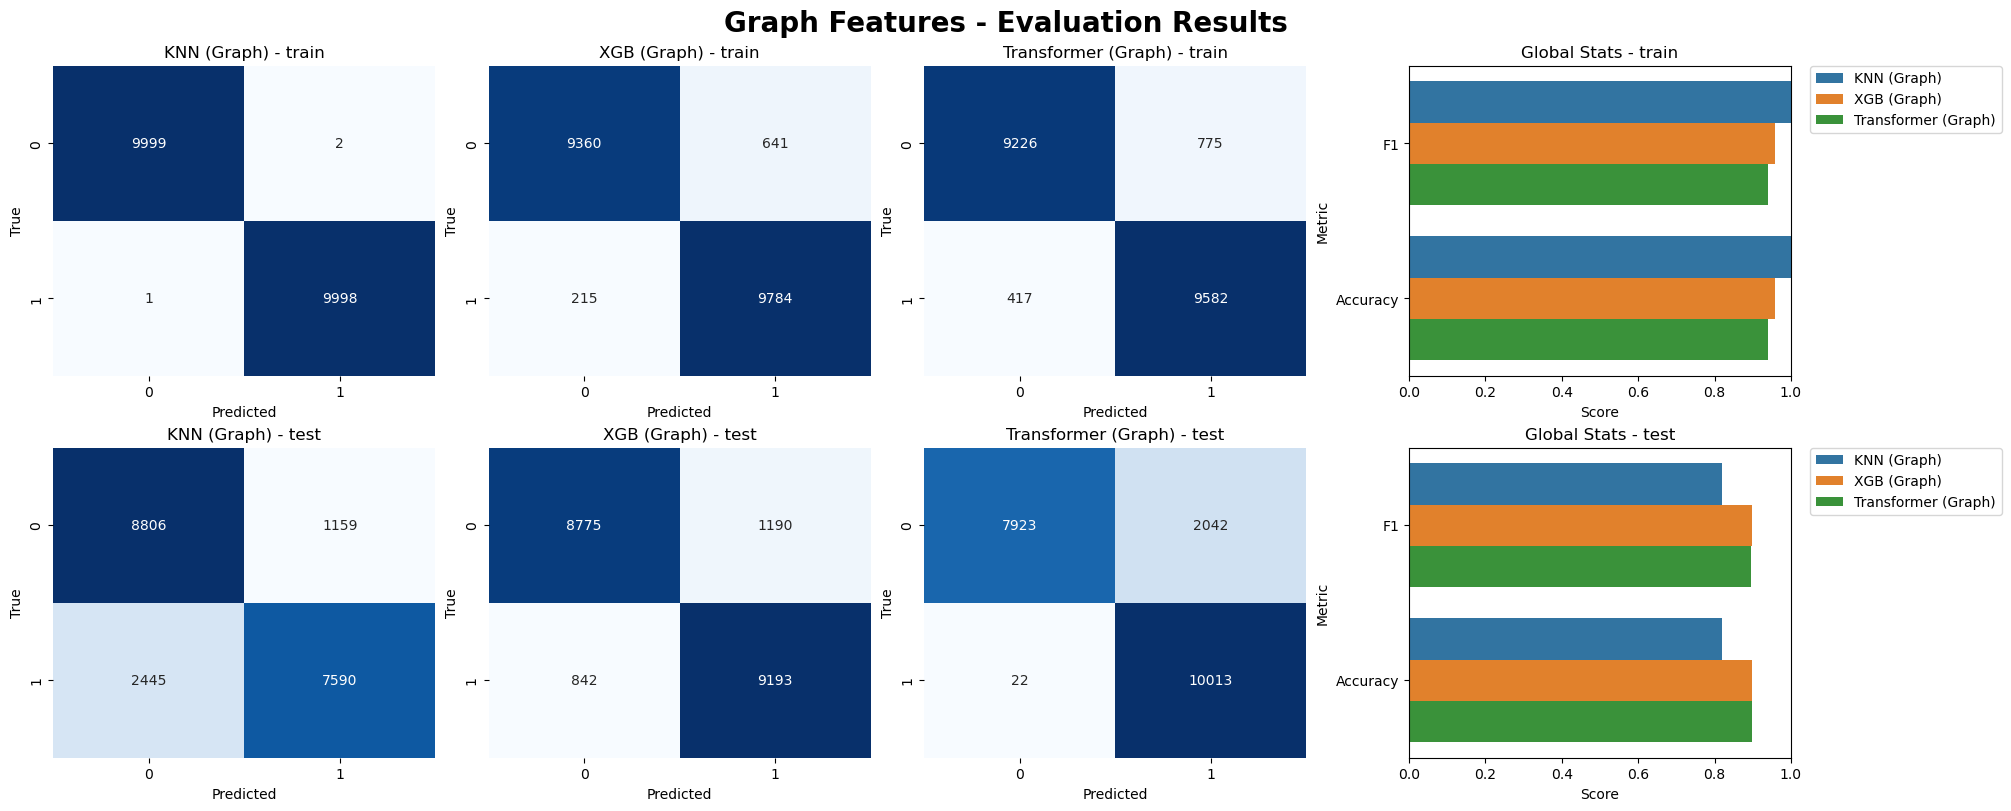

In [7]:
sets_for_graph = set_dict(datasets=[graph_train, graph_test], names=['train', 'test'])

graph_feat_models = [m for m in [graph_feat_knn, graph_feat_xgb, graph_feat_transformer] if m is not None]
graph_feat_names = []
if graph_feat_knn is not None:
    graph_feat_names.append('KNN (Graph)')
if graph_feat_xgb is not None:
    graph_feat_names.append('XGB (Graph)')
if graph_feat_transformer is not None:
    graph_feat_names.append('Transformer (Graph)')

if graph_feat_models:
    graph_feat_fig, graph_feat_metrics = plot_model_comparison(
        model_list=graph_feat_models,
        model_names=graph_feat_names,
        all_sets_list=[sets_for_graph] * len(graph_feat_models),
        title="Graph Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['graph_features'] = graph_feat_metrics
    comparison_figure_paths['graph_features'] = save_show_close(graph_feat_fig, 'eval_models_graph.png')
else:
    print("No models available for Graph Features")


### 2.3 Textual features

Textual 64 feature shapes: {'train': (2000, 128), 'test': (2000, 128)}


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


predict:   0%|          | 0/4 [00:00<?, ?it/s]

predict:   0%|          | 0/4 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_textual_64.png


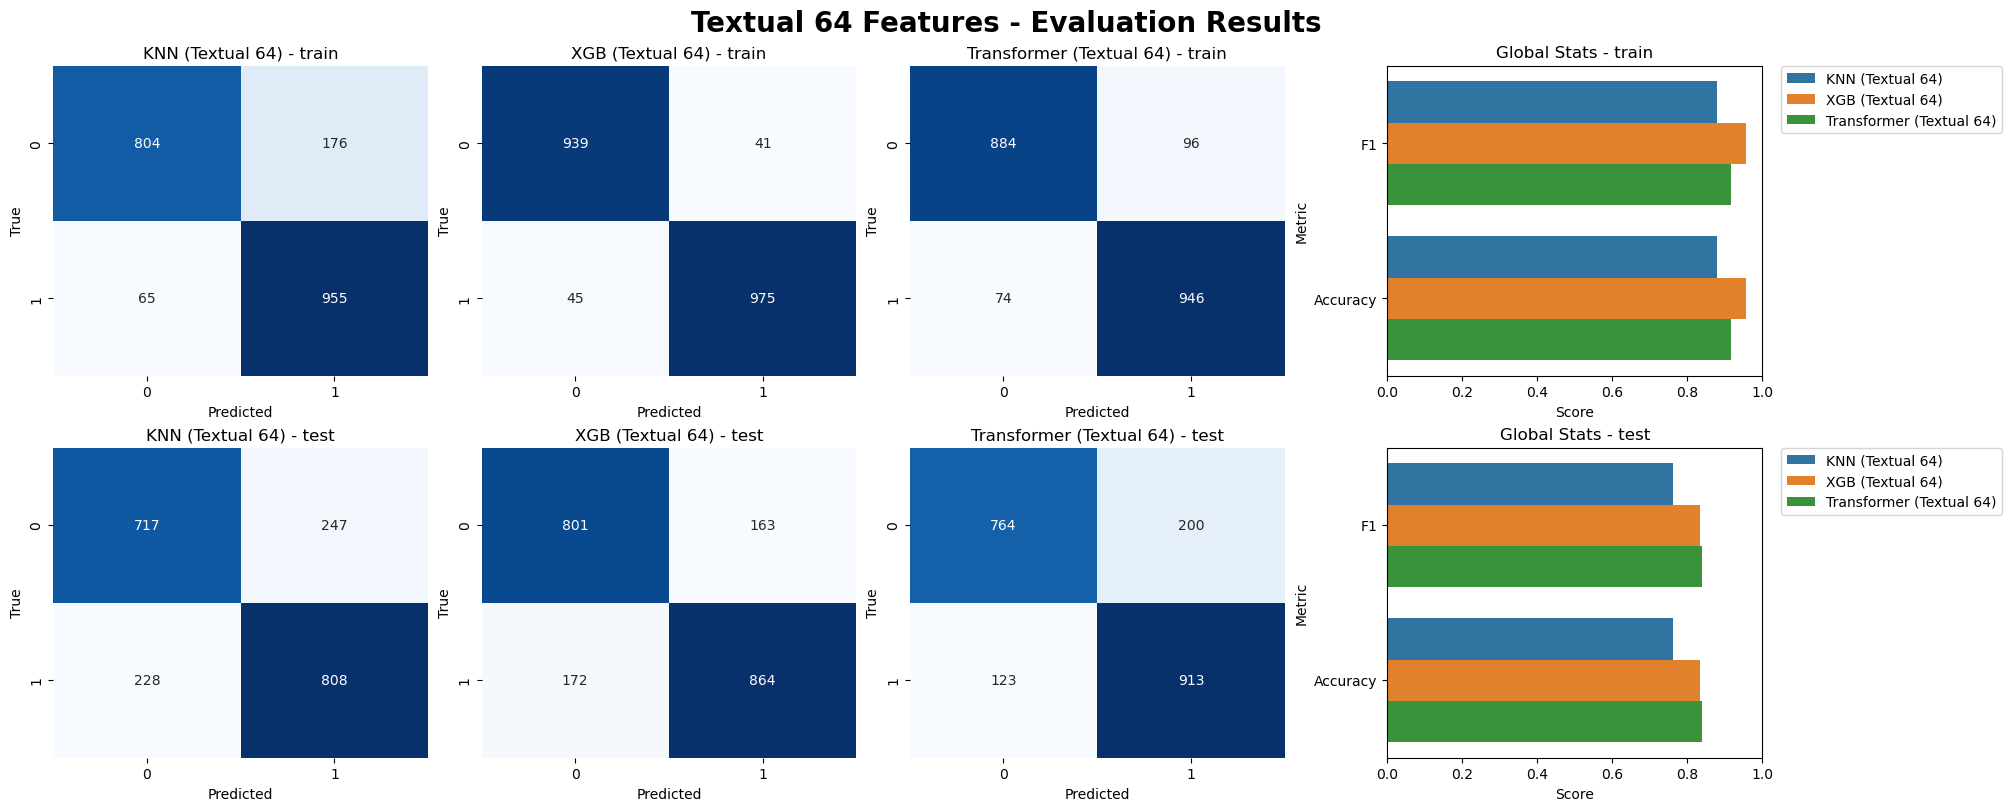

In [8]:
sets_for_text64 = set_dict(datasets=[text64_train, text64_test], names=['train', 'test'])
print("Textual 64 feature shapes:", {name: X.shape for name, (X, _) in sets_for_text64.items()})

text64_feat_models = [m for m in [text64_feat_knn, text64_feat_xgb, text64_feat_transformer] if m is not None]
text64_feat_names = []
if text64_feat_knn is not None:
    text64_feat_names.append('KNN (Textual 64)')
if text64_feat_xgb is not None:
    text64_feat_names.append('XGB (Textual 64)')
if text64_feat_transformer is not None:
    text64_feat_names.append('Transformer (Textual 64)')

if text64_feat_models:
    text64_feat_fig, text64_feat_metrics = plot_model_comparison(
        model_list=text64_feat_models,
        model_names=text64_feat_names,
        all_sets_list=[sets_for_text64] * len(text64_feat_models),
        title="Textual 64 Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['textual_embeddings_64'] = text64_feat_metrics
    comparison_figure_paths['textual_embeddings_64'] = save_show_close(text64_feat_fig, 'eval_models_textual_64.png')
else:
    print("No models available for Textual 64")


Textual 128 feature shapes: {'train': (2000, 256), 'test': (2000, 256)}


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


predict:   0%|          | 0/4 [00:00<?, ?it/s]

predict:   0%|          | 0/4 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_textual_128.png


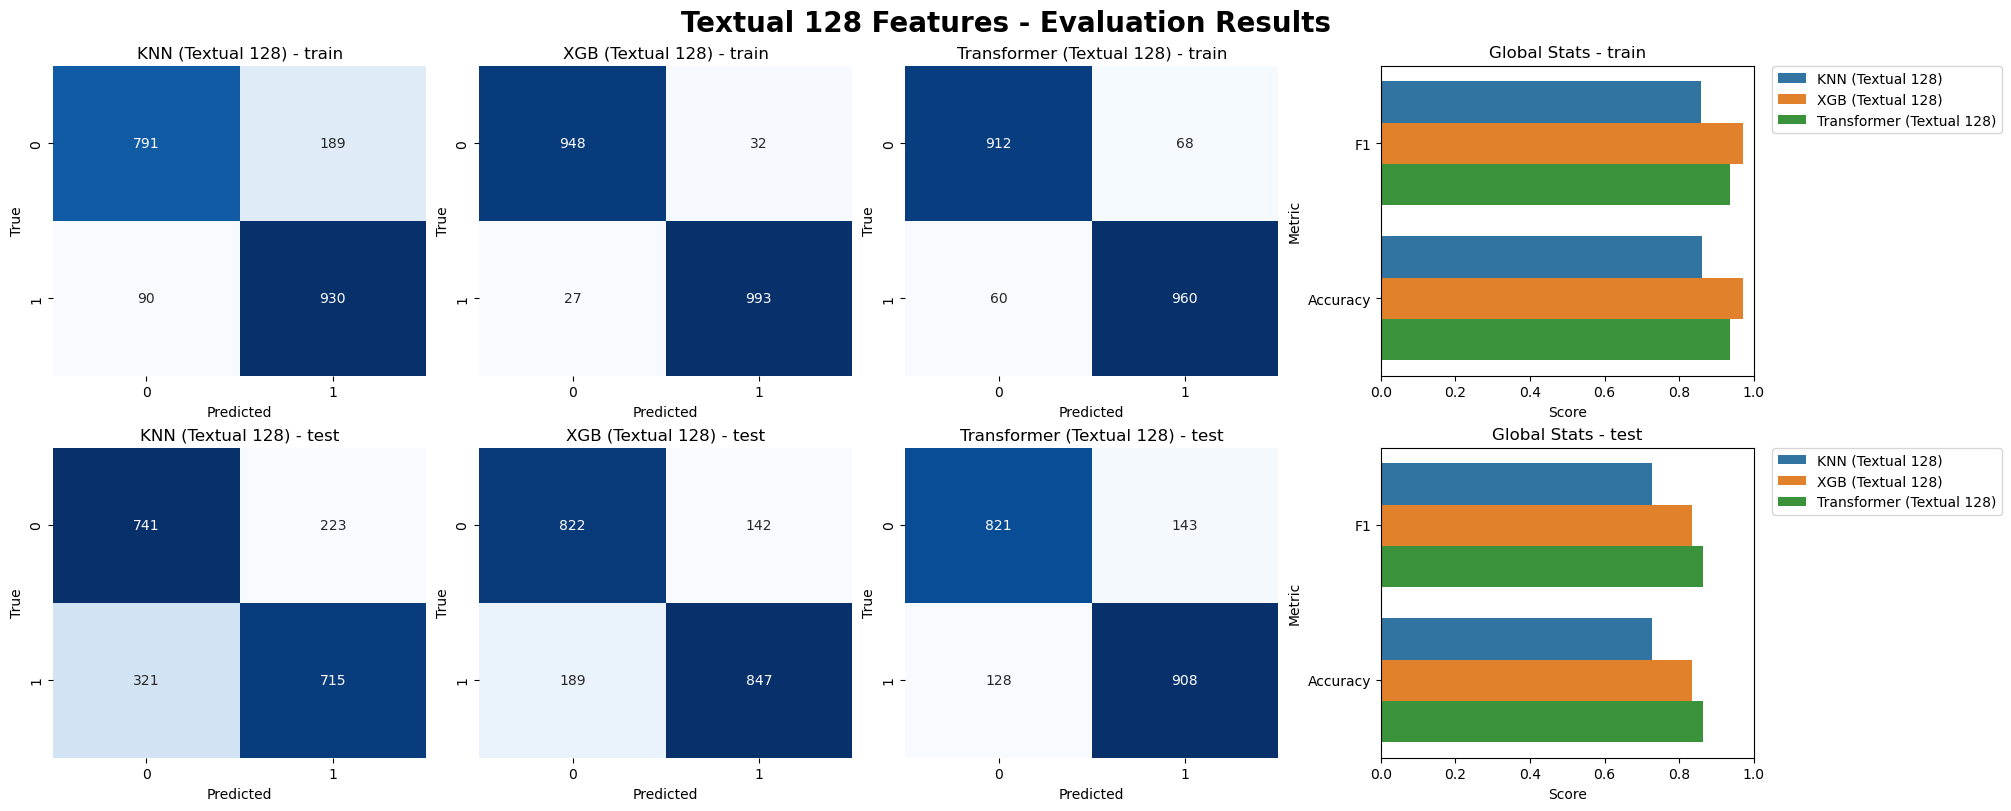

In [9]:
sets_for_text128 = set_dict(datasets=[text128_train, text128_test], names=['train', 'test'])
print("Textual 128 feature shapes:", {name: X.shape for name, (X, _) in sets_for_text128.items()})

text128_feat_models = [m for m in [text128_feat_knn, text128_feat_xgb, text128_feat_transformer] if m is not None]
text128_feat_names = []
if text128_feat_knn is not None:
    text128_feat_names.append('KNN (Textual 128)')
if text128_feat_xgb is not None:
    text128_feat_names.append('XGB (Textual 128)')
if text128_feat_transformer is not None:
    text128_feat_names.append('Transformer (Textual 128)')

if text128_feat_models:
    text128_feat_fig, text128_feat_metrics = plot_model_comparison(
        model_list=text128_feat_models,
        model_names=text128_feat_names,
        all_sets_list=[sets_for_text128] * len(text128_feat_models),
        title="Textual 128 Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['textual_embeddings_128'] = text128_feat_metrics
    comparison_figure_paths['textual_embeddings_128'] = save_show_close(text128_feat_fig, 'eval_models_textual_128.png')
else:
    print("No models available for Textual 128")


### 2.4 Combined features

/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [02:12:03] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This w

predict:   0%|          | 0/4 [00:00<?, ?it/s]

predict:   0%|          | 0/4 [00:00<?, ?it/s]

Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/eval_models_combined.png


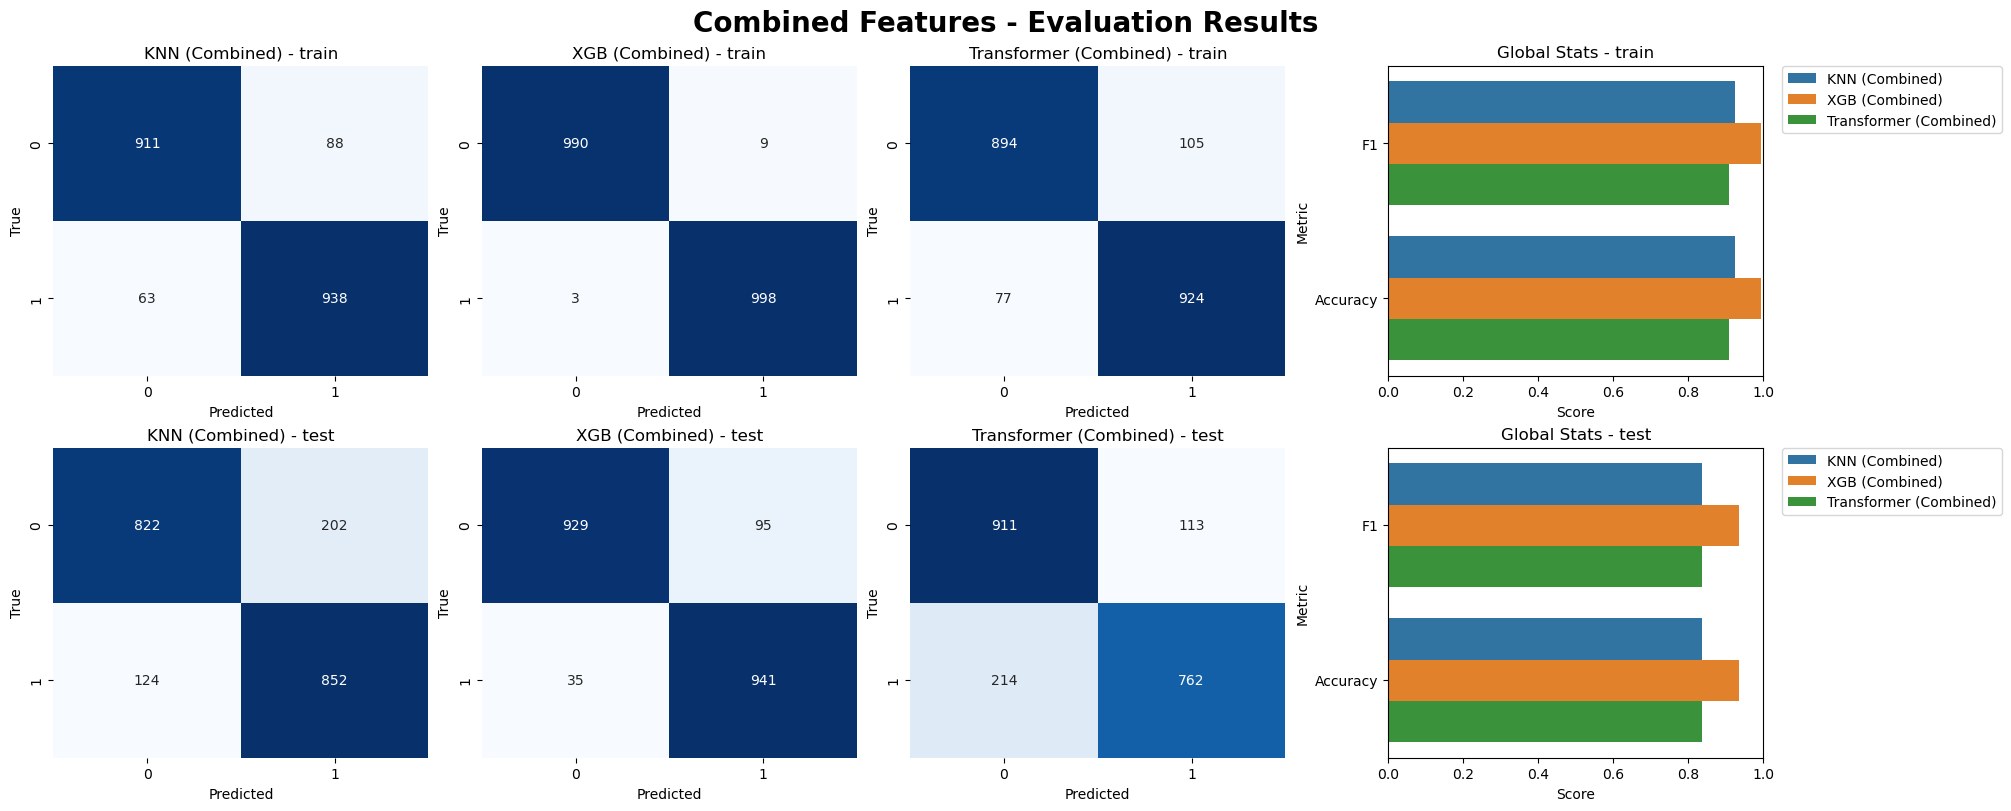

In [6]:
sets_for_mix = set_dict(datasets=[mix_train, mix_test], names=['train', 'test'])

mix_feat_models = [m for m in [all_feat_knn, all_feat_xgb, all_feat_transformer] if m is not None]
mix_feat_names = []
if all_feat_knn is not None:
    mix_feat_names.append('KNN (Combined)')
if all_feat_xgb is not None:
    mix_feat_names.append('XGB (Combined)')
if all_feat_transformer is not None:
    mix_feat_names.append('Transformer (Combined)')

if mix_feat_models:
    mix_feat_fig, mix_feat_metrics = plot_model_comparison(
        model_list=mix_feat_models,
        model_names=mix_feat_names,
        all_sets_list=[sets_for_mix] * len(mix_feat_models),
        title="Combined Features - Evaluation Results",
        figsize=(20, 8)
    )
    comparison_metrics['all_features'] = mix_feat_metrics
    comparison_figure_paths['all_features'] = save_show_close(mix_feat_fig, 'eval_models_combined.png')
else:
    print("No models available for Combined Features")


## 3. Global Comparison

### 3.1 All figures

In [7]:
# Figures are saved during each comparison cell and then closed to keep RAM and notebook size under control.
pd.Series(comparison_figure_paths, name='saved_figure')


all_features    /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_...
Name: saved_figure, dtype: object

> TODO comments

### 3.2 Heatmap of the stats

In [ ]:
#TODO: heatmap of the stats (each row is a model and each column a stat)

In [8]:
def plot_global_stats_heatmap(metrics_by_group, figsize=(12, 10)):
    """Collect test stats already computed by the plot cells and draw one global heatmap."""
    if not metrics_by_group:
        raise ValueError("No metrics available. Run the feature comparison cells first.")

    df_stats = pd.concat(metrics_by_group.values()).reset_index()
    df_stats = df_stats[df_stats['Set'] == 'test'].set_index('Model_Type')
    df_stats = df_stats[['F1', 'Accuracy', 'Precision', 'Recall']]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df_stats, annot=True, cmap='YlGnBu', fmt='.4f', cbar_kws={'label': 'Score'}, ax=ax)
    ax.set_title("Global Model Comparison - Test Set Metrics", fontsize=16, fontweight='bold')
    ax.set_ylabel("Model (Feature Set)")
    fig.tight_layout()

    comparison_figure_paths['global_stats_heatmap'] = save_show_close(fig, 'global_stats_heatmap.png')
    return df_stats


Saved figure: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/report/src/global_stats_heatmap.png


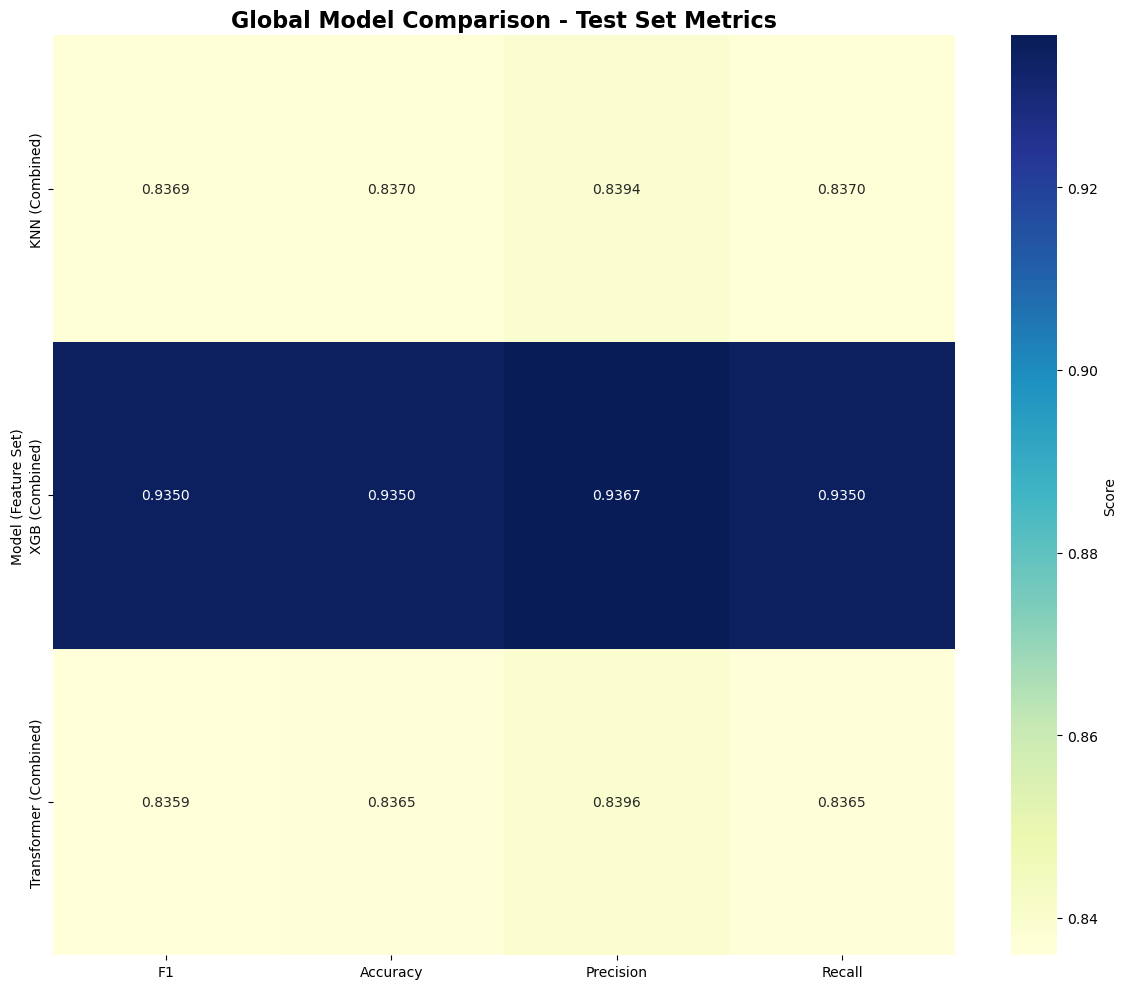

,F1,Accuracy,Precision,Recall
Model_Type,,,,
KNN (Combined),0.836905,0.8370,0.839362,0.8370
XGB (Combined),0.934988,0.9350,0.936662,0.9350
Transformer (Combined),0.835881,0.8365,0.839585,0.8365


In [9]:
global_test_metrics = plot_global_stats_heatmap(comparison_metrics)
global_test_metrics


> TODO comments